*© 2026 Paul Fergus. Free for student and research use — commercial use is strictly prohibited.*

# Lab 15 — Diffusion models: from noise to photorealistic images

**Module:** Deep Learning Concepts and Techniques (Computer Vision)
**Week:** 15
**Estimated time:** 210 minutes

---

## Learning outcomes

By the end of this lab you should be able to:

1. Explain the forward diffusion process as a sequence of small Gaussian noise injections, and implement the closed-form shortcut that samples any timestep directly, without looping.
2. Explain why the reverse (denoising) process cannot be computed analytically, what a diffusion model's training objective actually asks a network to learn, and why this is infeasible to train from scratch in a lab session.
3. Load and run a pretrained text-to-image diffusion model (Stable Diffusion) to generate novel images from text prompts.
4. Visualise the reverse process step by step, and explain classifier-free guidance mechanically — what it computes at every denoising step, and what changing `guidance_scale` actually does to the output.
5. Compare diffusion models against Lab 14's GAN and Lab 13's CLIP retrieval as three different solutions to representing and generating images.
6. Understand the licensing and ethical constraints attached to a pretrained generative model, and apply them responsibly.

## 1. From adversarial training to iterative refinement

Lab 14 built a GAN: a generator that produces an image in a single forward pass, trained by fooling a discriminator. It worked, but you also saw its failure modes first-hand — mode collapse, discriminator dominance, a notoriously unstable training signal from two networks with opposing objectives.

Diffusion models are the other major answer to "how do you generate a new image from nothing." Instead of one network guessing a finished image in one shot, a diffusion model asks a single network to make a small, well-defined improvement to a noisy image, then repeats that tens or hundreds of times. Today you will:

- Implement the **forward** process (adding noise) from first principles, exactly as you implemented self-attention from first principles in Lab 12 and the CLIP contrastive loss from first principles in Lab 13.
- Load a **pretrained** model for the reverse process (removing noise), for the same reason Lab 9 used a pretrained YOLOE and Lab 12 used a pretrained ViT-B/16 — training a diffusion U-Net from scratch takes GPU-days on millions of images, not a lab session.
- Watch that reverse process happen, one step at a time, and control it with **classifier-free guidance**.

## 2. The forward process: destroying structure on purpose

The forward process takes a real image $x_0$ and, over $T$ steps, adds a small amount of Gaussian noise at each step until, by step $T$, nothing recognisable remains — just noise. At step $t$, the amount of noise added is controlled by a **variance schedule** $\beta_t$: define $\alpha_t = 1 - \beta_t$ and $\bar\alpha_t = \prod_{i=1}^{t}\alpha_i$ (the cumulative product of every $\alpha$ up to $t$).

Doing this one small step at a time, $T$ times, would work but would be slow to sample from a dataset with. The useful mathematical fact is that the sum of many small Gaussian noise injections is *itself* Gaussian, which gives a **closed form** for jumping straight to any timestep $t$ in one line:

$$x_t = \sqrt{\bar\alpha_t}\, x_0 + \sqrt{1 - \bar\alpha_t}\, \epsilon, \qquad \epsilon \sim \mathcal{N}(0, I)$$

As $t \to T$, $\bar\alpha_t \to 0$, so $x_t$ becomes almost pure noise — $x_0$'s contribution vanishes and $\epsilon$'s dominates. Let's implement this directly and watch it happen to a real image.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from pathlib import Path

RNG_SEED = 7144
np.random.seed(RNG_SEED)
torch.manual_seed(RNG_SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

Device: cuda


Using one MNIST digit (label=5) as x0, shape (1, 28, 28)


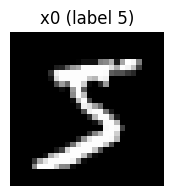

In [2]:
from torchvision import datasets, transforms

# Lab 14 already downloaded MNIST into its own data/ folder when you trained
# the DCGAN. We reuse that cache instead of pulling a second copy — the same
# fix Lab 12 applied to CIFAR-10 (see that lab's data-loading cell for why
# re-downloading inside this container is best avoided).
MNIST_ROOT = "../lab14_generative_models/data"
mnist = datasets.MNIST(root=MNIST_ROOT, train=True, download=True, transform=transforms.ToTensor())

digit_image, digit_label = mnist[0]
x0 = digit_image.unsqueeze(0).to(DEVICE)  # shape (1, 1, 28, 28), values in [0, 1]
print(f"Using one MNIST digit (label={digit_label}) as x0, shape {tuple(digit_image.shape)}")

plt.figure(figsize=(2, 2))
plt.imshow(digit_image.squeeze(), cmap="gray")
plt.title(f"x0 (label {digit_label})")
plt.axis("off")
plt.show()

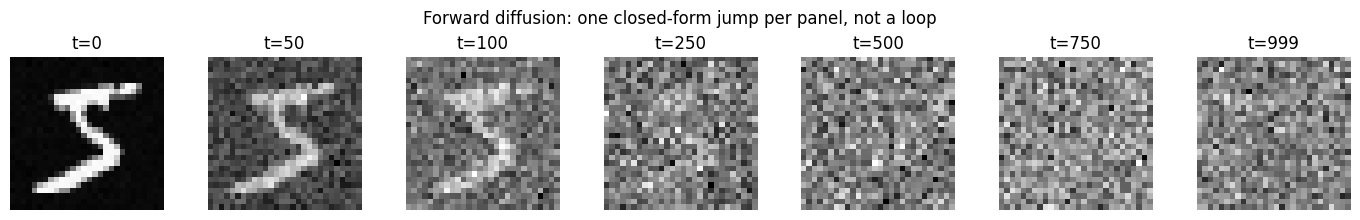

In [3]:
T = 1000
beta_start, beta_end = 1e-4, 2e-2
betas = torch.linspace(beta_start, beta_end, T, device=DEVICE)
alphas = 1.0 - betas
alpha_bars = torch.cumprod(alphas, dim=0)  # alpha_bar_t = product of alpha_1 ... alpha_t


def forward_diffusion(x0: torch.Tensor, t: int, alpha_bars: torch.Tensor):
    """Closed-form q(x_t | x0): sample x_t in ONE step, without actually
    looping through t individual noise-adding steps. This shortcut exists
    because the sum of many small Gaussian noise injections is itself
    Gaussian — see Section 2's derivation.
    """
    a_bar = alpha_bars[t]
    noise = torch.randn_like(x0)
    xt = torch.sqrt(a_bar) * x0 + torch.sqrt(1.0 - a_bar) * noise
    return xt, noise


timesteps_to_show = [0, 50, 100, 250, 500, 750, 999]
fig, axes = plt.subplots(1, len(timesteps_to_show), figsize=(2 * len(timesteps_to_show), 2.2))
for ax, t in zip(axes, timesteps_to_show):
    xt, _ = forward_diffusion(x0, t, alpha_bars)
    ax.imshow(xt.squeeze().cpu(), cmap="gray")
    ax.set_title(f"t={t}")
    ax.axis("off")
plt.suptitle("Forward diffusion: one closed-form jump per panel, not a loop")
plt.tight_layout()
plt.show()

## 3. The reverse process: undoing noise, one learned step at a time

The forward process above is fixed and requires no learning — it is just adding noise according to a formula. Generation needs the *opposite* direction: starting from pure noise $x_T$ and recovering a plausible image $x_0$. That direction has no closed form, because "undo this noise" requires knowing what structure was actually there — information the forward process threw away.

This is what a diffusion model learns: a neural network $\epsilon_\theta(x_t, t)$ that looks at a noisy image $x_t$ and the timestep $t$, and predicts the noise $\epsilon$ that was added to produce it. Training minimises the mean squared error between the network's prediction and the actual noise used in Section 2's forward step — a single, well-behaved regression loss, with none of Lab 14's adversarial instability. Once trained, generation runs this network repeatedly: predict the noise in $x_t$, subtract a calibrated fraction of it to get $x_{t-1}$, and repeat from $t=T$ down to $t=0$.

**Why we are not training this network ourselves.** The network above is a large U-Net (tens to hundreds of millions of parameters), and a usable one is trained on hundreds of millions of image-text pairs over many GPU-days. That is the same infeasibility Lab 9 hit with YOLOE and Lab 12 hit with ViT-B/16 pretraining — so, exactly as in those labs, we load a network someone else already trained, and put our effort into understanding and controlling it rather than reproducing its training run.

## 4. Loading a pretrained diffusion model

We use [Stable Diffusion v1.5](https://huggingface.co/stable-diffusion-v1-5/stable-diffusion-v1-5) via Hugging Face's `diffusers` library — a text-to-image model built from exactly the pieces described in Section 3: a U-Net that predicts noise, plus a text encoder that conditions that prediction on your prompt, plus a VAE that translates between pixel space and the smaller latent space the U-Net actually operates in (which is why what the U-Net denoises is called a *latent*, not a pixel image).

In [4]:
from diffusers import AutoPipelineForText2Image

MODEL_ID = "stable-diffusion-v1-5/stable-diffusion-v1-5"
MODEL_CACHE = Path("data/hf_cache")
MODEL_CACHE.mkdir(parents=True, exist_ok=True)

# Match precision to what the hardware can actually run: fp16 halves both the
# download size and the VRAM footprint on a GPU, but several fp16 kernels are
# unimplemented on CPU, so we fall back to fp32 there. This lab assumes the
# same CUDA GPU every lab since Lab 7 has required.
USE_FP16 = DEVICE.type == "cuda"
pipe_kwargs = dict(cache_dir=MODEL_CACHE, use_safetensors=True)
if USE_FP16:
    pipe_kwargs.update(torch_dtype=torch.float16, variant="fp16")
else:
    pipe_kwargs.update(torch_dtype=torch.float32)

# Cached under this lab's own data/ folder (bind-mounted to the host), so the
# ~2 GB download survives container rebuilds instead of vanishing with the
# container's writable layer — the same reasoning behind every other lab's
# local data/ cache in this module.
pipe = AutoPipelineForText2Image.from_pretrained(MODEL_ID, **pipe_kwargs).to(DEVICE)
pipe.set_progress_bar_config(disable=True)
pipe.enable_attention_slicing()  # trades a little speed for a lot less VRAM; cheap insurance
print(f"Loaded {MODEL_ID} in {pipe.unet.dtype} on {DEVICE}")

/usr/local/lib/python3.11/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[transformers] `Siglip2ImageProcessorFast` is deprecated. The `Fast` suffix for image processors has been removed; use `Siglip2ImageProcessor` instead.
/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(
Loading pipeline components...: 100%|██████████| 7/7 [00:00<00:00,  7.47it/s]


Loaded stable-diffusion-v1-5/stable-diffusion-v1-5 in torch.float16 on cuda


**A familiar face inside the pipeline.** The text encoder that turns your prompt into the embedding the U-Net conditions on is not a new architecture — it is a CLIP text transformer, the same kind of model Lab 13 opened up and built the contrastive loss for (a different trained checkpoint, but the same `CLIPTextModel` architecture). Confirm it directly rather than taking that on faith:

In [5]:
print(f"Text encoder class: {type(pipe.text_encoder).__name__}")
print(f"Tokenizer class:    {type(pipe.tokenizer).__name__}")
print(f"UNet parameters:    {sum(p.numel() for p in pipe.unet.parameters()) / 1e6:.1f}M")

Text encoder class: CLIPTextModel
Tokenizer class:    CLIPTokenizer
UNet parameters:    859.5M


## 5. Generating your first image

Everything from here runs the reverse process for you: start from random noise in latent space, and run the U-Net's noise prediction `num_inference_steps` times, each time removing a calibrated amount of predicted noise, conditioned throughout on your text prompt's CLIP embedding.

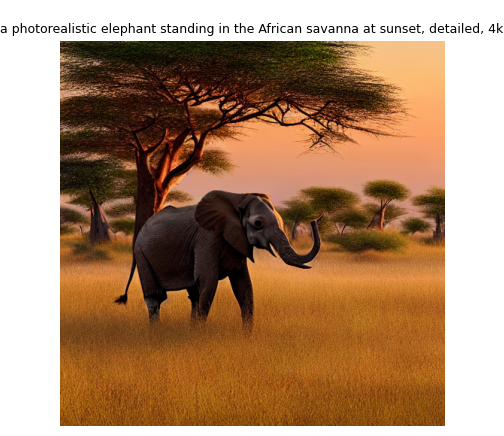

In [6]:
PROMPT = "a photorealistic elephant standing in the African savanna at sunset, detailed, 4k"

generator = torch.Generator(device=DEVICE).manual_seed(RNG_SEED)
result = pipe(prompt=PROMPT, num_inference_steps=30, guidance_scale=7.5, generator=generator)
image = result.images[0]

plt.figure(figsize=(5, 5))
plt.imshow(image)
plt.axis("off")
plt.title(PROMPT, fontsize=9, wrap=True)
plt.show()

## 6. Watching the reverse process happen

Section 3 described generation as repeatedly predicting and subtracting noise. `diffusers` lets us look inside that loop with `callback_on_step_end`, which hands back the current latent at any step we ask for. Decoding an *intermediate* latent through the VAE — instead of only the final one — lets us watch the image resolve out of noise, step by step, rather than just seeing the finished result.

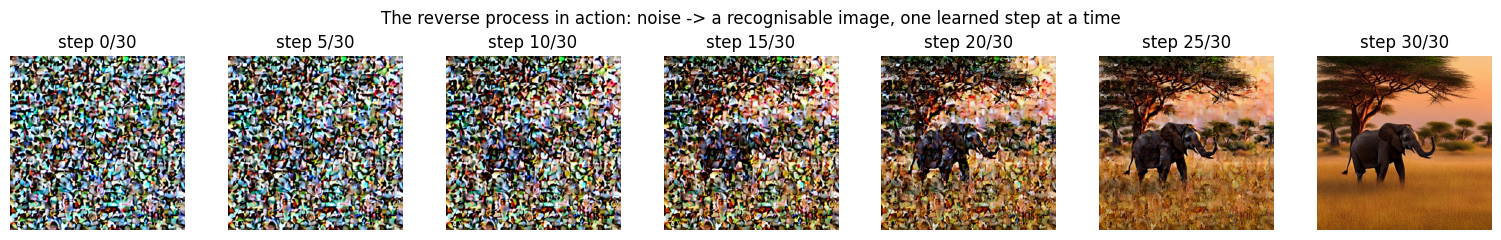

In [7]:
def decode_latents_to_image(pipe, latents):
    """Run a captured intermediate latent through the VAE decoder to see what
    the image looks like at that point in the reverse process — exactly what
    the pipeline itself does to the FINAL latent, just done early.
    """
    scaled = latents / pipe.vae.config.scaling_factor
    with torch.no_grad():
        decoded = pipe.vae.decode(scaled.to(pipe.vae.dtype)).sample
    decoded = (decoded / 2 + 0.5).clamp(0, 1)
    decoded = decoded.cpu().permute(0, 2, 3, 1).float().numpy()
    return decoded[0]


captured = []

def capture_every_5th_step(pipe, step_index, timestep, callback_kwargs):
    if step_index % 5 == 0:
        captured.append((step_index, callback_kwargs["latents"].detach().clone()))
    return callback_kwargs


NUM_STEPS = 30
generator = torch.Generator(device=DEVICE).manual_seed(RNG_SEED)
result = pipe(
    prompt=PROMPT,
    num_inference_steps=NUM_STEPS,
    guidance_scale=7.5,
    generator=generator,
    callback_on_step_end=capture_every_5th_step,
    callback_on_step_end_tensor_inputs=["latents"],
)

fig, axes = plt.subplots(1, len(captured), figsize=(2.2 * len(captured), 2.4))
for ax, (step_index, latents) in zip(axes, captured):
    ax.imshow(decode_latents_to_image(pipe, latents))
    ax.set_title(f"step {step_index}/{NUM_STEPS}")
    ax.axis("off")
plt.suptitle("The reverse process in action: noise -> a recognisable image, one learned step at a time")
plt.tight_layout()
plt.show()

## 7. Classifier-free guidance

At every denoising step, the U-Net actually makes **two** noise predictions from the same noisy latent: one conditioned on your prompt's embedding ($\epsilon_{cond}$), and one conditioned on an empty prompt ($\epsilon_{uncond}$). The prediction actually used to step the latent is an extrapolation between them:

$$\epsilon = \epsilon_{uncond} + \text{guidance\_scale} \cdot (\epsilon_{cond} - \epsilon_{uncond})$$

At `guidance_scale=1.0` this collapses to $\epsilon_{cond}$ alone — no push away from the unconditional prediction, so the prompt has minimal influence beyond ordinary conditioning. Raising `guidance_scale` pushes the trajectory further in the direction the *text* pulls it relative to no text at all — stronger prompt adherence, but past a point, oversaturated colours and distorted structure, because the model is being extrapolated further from anything it was actually trained to output directly.

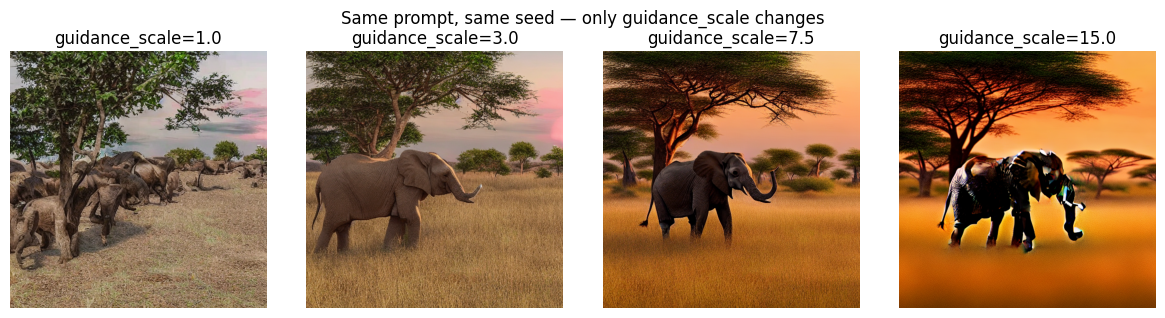

In [8]:
guidance_scales = [1.0, 3.0, 7.5, 15.0]
fig, axes = plt.subplots(1, len(guidance_scales), figsize=(3 * len(guidance_scales), 3.2))
for ax, gs in zip(axes, guidance_scales):
    generator = torch.Generator(device=DEVICE).manual_seed(RNG_SEED)
    img = pipe(prompt=PROMPT, num_inference_steps=30, guidance_scale=gs, generator=generator).images[0]
    ax.imshow(img)
    ax.set_title(f"guidance_scale={gs}")
    ax.axis("off")
plt.suptitle("Same prompt, same seed — only guidance_scale changes")
plt.tight_layout()
plt.show()

## 8. Negative prompts

`negative_prompt` uses exactly the same mechanism as Section 7, except $\epsilon_{uncond}$ is no longer computed from an *empty* prompt — it is computed from **your** negative text. The model is then pushed away from whatever that describes, not merely away from "nothing in particular."

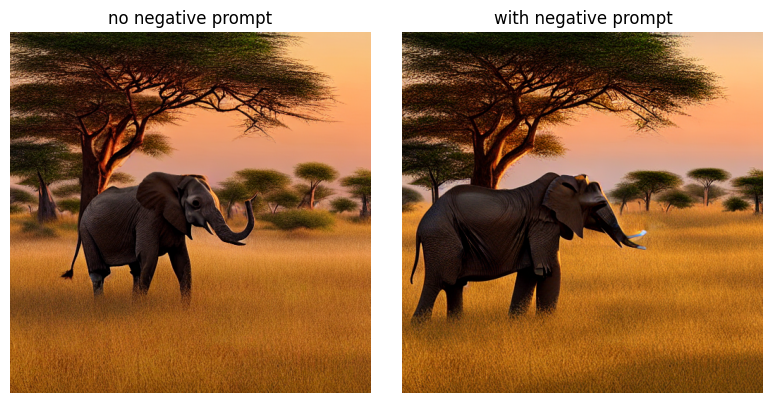

In [9]:
NEG_PROMPT = "blurry, low quality, deformed, extra limbs, watermark, text"

generator = torch.Generator(device=DEVICE).manual_seed(RNG_SEED)
img_no_neg = pipe(prompt=PROMPT, num_inference_steps=30, guidance_scale=7.5, generator=generator).images[0]

generator = torch.Generator(device=DEVICE).manual_seed(RNG_SEED)
img_with_neg = pipe(prompt=PROMPT, negative_prompt=NEG_PROMPT, num_inference_steps=30, guidance_scale=7.5, generator=generator).images[0]

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(img_no_neg); axes[0].set_title("no negative prompt"); axes[0].axis("off")
axes[1].imshow(img_with_neg); axes[1].set_title("with negative prompt"); axes[1].axis("off")
plt.tight_layout()
plt.show()

## 9. Generating the wildlife species — and checking against reality

Every earlier lab from Lab 6 onward worked with *real* wildlife photographs. Today, for the first time in this module, generate images of the same four species from nothing but text, and compare a generated image directly against a real photo from Lab 6's dataset.

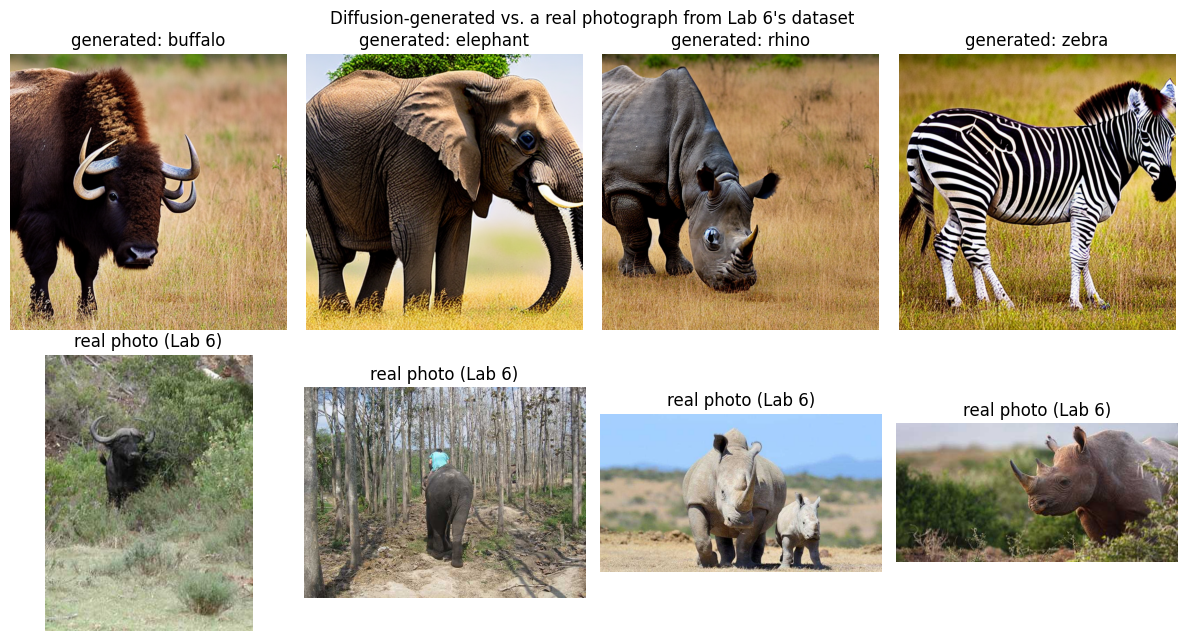

In [10]:
from PIL import Image

DATA_ROOT = Path("../lab06_image_annotation/data")
CLASS_NAMES = ["buffalo", "elephant", "rhino", "zebra"]


def find_one_real_example(class_id: int, split: str = "train"):
    """Scan Lab 6's YOLO-format labels for one image whose first annotation
    is this class. Filenames don't encode species — only the label files do
    (first column of each line is the class id) — so we have to read them.
    """
    label_dir = DATA_ROOT / "labels" / split
    for label_path in sorted(label_dir.glob("*.txt")):
        first_class = int(label_path.read_text().split()[0])
        if first_class == class_id:
            return DATA_ROOT / "images" / split / f"{label_path.stem}.jpg"
    return None


real_examples = {name: find_one_real_example(i) for i, name in enumerate(CLASS_NAMES)}

fig, axes = plt.subplots(2, len(CLASS_NAMES), figsize=(3 * len(CLASS_NAMES), 6.5))
for col, species in enumerate(CLASS_NAMES):
    generator = torch.Generator(device=DEVICE).manual_seed(RNG_SEED)
    prompt = f"a photorealistic {species} standing in the African savanna, wildlife photography, detailed, sharp focus"
    gen_img = pipe(prompt=prompt, negative_prompt=NEG_PROMPT, num_inference_steps=30, guidance_scale=7.5, generator=generator).images[0]
    axes[0, col].imshow(gen_img)
    axes[0, col].set_title(f"generated: {species}")
    axes[0, col].axis("off")

    real_img = Image.open(real_examples[species])
    axes[1, col].imshow(real_img)
    axes[1, col].set_title("real photo (Lab 6)")
    axes[1, col].axis("off")

plt.suptitle("Diffusion-generated vs. a real photograph from Lab 6's dataset")
plt.tight_layout()
plt.show()

## 10. Three generative paradigms, side by side

You have now built or used all three of this module's approaches to representing and generating images. They are not interchangeable — each is the right tool for a different job:

| | GAN (Lab 14) | Diffusion (today) | CLIP retrieval (Lab 13) |
|---|---|---|---|
| Generates new pixels? | Yes | Yes | No — retrieves an existing image |
| Training signal | Adversarial minimax, two networks | Single network, noise-prediction MSE | Contrastive loss over image-text pairs |
| Sampling cost | One forward pass | Tens to hundreds of iterative denoising steps | One embedding + nearest-neighbour lookup |
| Training stability | Prone to mode collapse and discriminator dominance (your own Lab 14 diagnostics) | Single well-behaved regression loss, generally stable | Single well-behaved contrastive loss |
| Text-conditioning | Not in Lab 14's DCGAN (unconditional) | Native, via a CLIP text encoder | Native — it is the entire mechanism |
| Cost per sample | Cheap | Expensive | Cheap |

None of this makes one approach strictly "better" — a production system generating millions of thumbnails per day cannot afford diffusion's per-sample cost, and a text-to-image search engine like Lab 13's has no pixels to generate in the first place. Matching the tool to the constraint is the actual skill.

## 11. Ethics and licensing

Stable Diffusion v1.5 is released under the **CreativeML OpenRAIL-M license** — an "Open Responsible AI License" that permits broad use, including commercial use, but has specific prohibited uses written into the license itself rather than left to a separate terms-of-service page. Named restrictions include generating demeaning or dehumanising representations of people or their cultures, impersonating real individuals without consent, generating non-consensual sexual content, misinformation, and disinformation, and depicting egregious violence.

Two practical points worth carrying forward:

- **Provenance.** Models like this are trained on very large, largely web-scraped image-text datasets. Whether a given generated image incorporates a specific artist's or photographer's identifiable style or work, and what that means for attribution and copyright, remains genuinely unsettled law in most jurisdictions as of writing — treat generated images as carrying real provenance questions, not as a clean-room creation.
- **Coursework and portfolios.** Check a model's specific license before using its output commercially or in a portfolio, and never present a generated image as a photograph you took. Both of the images you generated in Section 9 are exactly this kind of case — compare how you would (and would not) be able to caption them next to the real Lab 6 photo above.

---

## 12. Exercise 1 — guidance scale, further

Repeat Section 7's sweep with a wider range: `guidance_scale` in `[1.0, 5.0, 10.0, 20.0, 30.0]`, same prompt and seed. In 2-3 sentences, identify roughly where output quality peaks and describe the specific failure mode you observe at the high end (oversaturated colour, warped anatomy, something else).

In [ ]:
# Your code for Exercise 1 here.

*Your findings:*

## 13. Exercise 2 — negative prompts, deliberately

Pick a prompt likely to produce a specific unwanted artefact (extra limbs, a watermark-like texture, an unwanted background element — anything you can predict in advance). Generate it once with no negative prompt and once with a `negative_prompt` targeting that specific artefact. Show both images and explain, using Section 8's mechanism, why the difference occurs.

In [ ]:
# Your code for Exercise 2 here.

*Your findings:*

## 14. Exercise 3 — open-ended (pick one)

**Option A — Prompt interpolation.** Encode two different prompts into text embeddings with `pipe.encode_prompt(...)`, linearly interpolate between the two embeddings at several points, and generate an image at each point with `pipe(prompt_embeds=..., ...)` instead of `prompt=...`. Does the sequence move smoothly between the two concepts, or jump abruptly?

**Option B — Steps vs. quality vs. time.** Generate the same prompt at `num_inference_steps` in `[5, 10, 20, 30, 50]`, timing each with Python's `time` module. Plot quality (your own judgement) and wall-clock time against step count. Where are the diminishing returns?

**Option C — Image-to-image.** `diffusers` can reuse your already-loaded pipeline's weights for image-to-image generation with no second download: `from diffusers import AutoPipelineForImage2Image; img2img_pipe = AutoPipelineForImage2Image.from_pipe(pipe)` (if `from_pipe` is unavailable in your installed version, load it fresh with `AutoPipelineForImage2Image.from_pretrained(MODEL_ID, **pipe_kwargs)` instead). Feed it one of Section 9's real Lab 6 photos and generate variations at a few different `strength` values (how far back into the noising process the starting image is pushed before denoising resumes). What does `strength` control, concretely, in terms of Section 2's forward process?

In [ ]:
# Your code for Exercise 3 (Option A, B, or C) here.

*Which option did you pick, and what did you find?*

---

## 15. Reflection questions

**Q1.** Section 2 used a closed-form shortcut to jump straight to $x_t$ instead of looping through $t$ individual noise-adding steps. What specifically would looping step by step have given you that the closed form does not, if anything — or are the two genuinely equivalent? Justify your answer from the derivation, not just the code output.

**Q2.** Section 3 explained that the reverse process has no closed form because "undo this noise" requires information the forward process discarded. Explain specifically what a diffusion model's noise-prediction network is learning to recover, and why a simple MSE regression loss is a workable training signal for learning it despite that.

**Q3.** Using the $\epsilon = \epsilon_{uncond} + \text{guidance\_scale} \cdot (\epsilon_{cond} - \epsilon_{uncond})$ formula from Section 7, explain mechanically what happens at `guidance_scale=1.0` versus a very high value like 20-30. Which failure mode did you actually observe at the high end in your own sweep, if any?

**Q4.** Compare the training stability and sampling cost of Lab 14's DCGAN against today's diffusion model. Which would you choose for a production system needing millions of images generated per day at low latency, and which for a system generating a handful of high-quality images where quality matters far more than speed? Justify both answers.

**Q5.** Stable Diffusion v1.5's CreativeML OpenRAIL-M license permits broad use, including commercial, but names specific prohibited uses inside the license itself rather than a separate terms page. Pick one of those named restrictions from Section 11 and describe a concrete, realistic scenario where a developer with no bad intent could end up violating it anyway.

*Your answers:*

**A1.**

**A2.**

**A3.**

**A4.**

**A5.**

---

## What's next

That closes the arc of this module: fifteen labs from a perceptron implemented by hand in numpy, through CNNs, custom image pipelines, object detection you trained and then honestly evaluated, zero-shot detection, instance segmentation with a foundation model, explainability tools that audit a network's own reasoning, the inductive-bias trade-off between CNNs and Vision Transformers, a multi-modal embedding space you built the contrastive loss for, GANs and autoencoders, and today, a diffusion model turning text into photorealistic images — using, underneath, the very same CLIP text encoder architecture Lab 13 opened up.

The specific architectures in this field will keep changing, faster than most. What should stay with you regardless: **look at your actual data and your actual output, not just the aggregate number (every lab); measure honestly, with a genuinely independent test set (Lab 8); understand what a model assumes, and what it was and wasn't trained to do, before you trust it (Labs 1, 9, 11, 12, and today's licensing section); and know the cost and stability trade-offs between the tools available to you well enough to pick the right one on purpose (today's Section 10, and really, every lab that offered you a choice).**

Before leaving today, make sure:

- [ ] You implemented the forward diffusion process from first principles and watched a real digit dissolve into noise
- [ ] You loaded a pretrained Stable Diffusion pipeline and generated images from text prompts
- [ ] You watched the reverse process happen step by step via the denoising callback
- [ ] You ran the guidance_scale sweep and can explain what the parameter does mechanically
- [ ] You compared a generated wildlife image against a real Lab 6 photo
- [ ] You completed Exercises 1, 2, and 3
- [ ] You answered the reflection questions
- [ ] Your notebook runs **top to bottom without errors**